# [Unsloth](https://unsloth.ai/)

Unsloth는 대규모 언어 모델(LLM)의 파인튜닝(Fine-tuning) 속도를 극적으로 높이고 메모리 사용량을 줄여주는 오픈소스 프레임워크입니다.

## Unsloth 장점 

- `압도적인 속도`: Hugging Face의 기본 학습 방식보다 보통 2배에서 5배까지 더 빠릅니다. (이미지에서 보신 것처럼 "2x faster"라는 문구가 뜨는 이유입니다.)

- `메모리 효율성 (0% 메모리 단편화)`: GPU 메모리를 매우 알뜰하게 사용합니다. 덕분에 메모리가 부족해서 발생하는 Out of Memory (OOM) 에러를 획기적으로 줄여주며, 더 큰 배치 사이즈나 긴 문장(max_seq_length)을 학습시킬 수 있습니다.

- `정확도 유지`: 속도는 빠르지만 모델의 품질(정확도)은 떨어뜨리지 않습니다. 수학적으로 최적화된 커널(Triton)을 사용하여 계산 효율만 높였기 때문입니다.

- `쉬운 사용법`: 기존 Hugging Face의 SFTTrainer나 TRL 라이브러리와 완벽하게 호환되도록 설계되어, 기존 코드를 아주 조금만 수정해도 바로 사용할 수 있습니다.

## Unsloth LoRA / QLoRA 장점

| 관점           | 장점                  | 설명                                  |
| ------------ | ------------------- | ----------------------------------- |
| 🚀 속도        | **학습 속도 매우 빠름**     | 커스텀 CUDA 커널 + 최적화된 forward/backward |
| 💾 메모리       | **VRAM 사용량 최소**     | 4bit 로딩 + QLoRA 기본 설계               |
| 🧠 난이도       | **설정이 단순함**         | YAML 없음, Python 몇 줄로 끝              |
| 🧪 실험        | **빠른 반복 실험 가능**     | 하이퍼파라미터 변경 부담 낮음                    |
| 💻 하드웨어      | **단일 GPU로 충분**      | 24GB GPU에서도 7B~13B 가능               |
| 🎓 강의        | **입문자 친화적**         | 멀티 GPU / 분산 개념 없이 설명 가능             |
| 🧩 통합        | **Transformers 호환** | HF Trainer / PEFT 생태계 그대로 사용        |
| 🔄 저장        | **HF Hub 업로드 간단**   | `push_to_hub()` 바로 가능               |
| 🛠 디버깅       | **에러 지점 명확**        | 분산/ZeRO 개념 없음                       |
| 🧑‍💻 개발 생산성 | **코드 가독성 높음**       | “무슨 일이 일어나는지” 바로 보임                 |

## [Unsloth Models](https://docs.unsloth.ai/get-started/all-our-models)

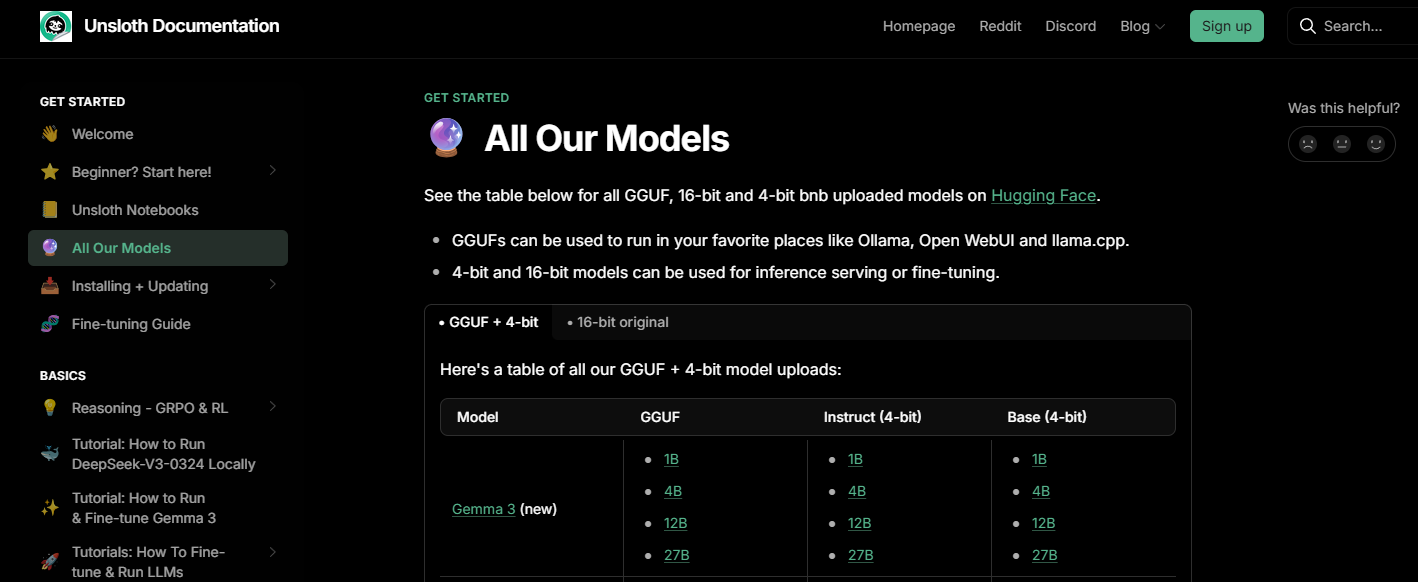

# [예제](https://docs.unsloth.ai/get-started/unsloth-notebooks)

### API 등록
- [WandB API](https://wandb.ai/authorize)
- [HuggingFace API Key](https://huggingface.co/settings/tokens)

In [ ]:
from dotenv import load_dotenv

# .env 파일에 기록된 환경 변수를 시스템으로 불러옵니다.
load_dotenv() 


## [Load Model](https://huggingface.co/unsloth)

In [ ]:
from unsloth import FastModel
import torch

fourbit_models = [
    # 4bit dynamic quants for superior accuracy and low memory use
    "unsloth/gemma-3-1b-it-unsloth-bnb-4bit",
    "unsloth/gemma-3-4b-it-unsloth-bnb-4bit",
    "unsloth/gemma-3-12b-it-unsloth-bnb-4bit",
    "unsloth/gemma-3-27b-it-unsloth-bnb-4bit",

    # Other popular models!
    "unsloth/Llama-3.1-8B",
    "unsloth/Llama-3.2-3B",
    "unsloth/Llama-3.3-70B",
    "unsloth/mistral-7b-instruct-v0.3",
    "unsloth/Phi-4",
] # More models at https://huggingface.co/unsloth

model, tokenizer = FastModel.from_pretrained(
    model_name = "unsloth/gemma-3-1b-it",
    max_seq_length = 8184, # Choose any for long context!
    load_in_4bit = True,  # 4 bit quantization to reduce memory
    load_in_8bit = False, # [NEW!] A bit more accurate, uses 2x memory
    full_finetuning = False, # [NEW!] We have full finetuning now!
    # token = "hf_...", # use one if using gated models
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.12.5: Fast Gemma3 patching. Transformers: 4.57.3.
   \\   /|    NVIDIA RTX A5000. Num GPUs = 1. Max memory: 23.673 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.5.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Gemma3 does not support SDPA - switching to fast eager.


## PEFT : QLoRA

In [5]:
model = FastModel.get_peft_model(
    model,
    finetune_vision_layers     = False, # Turn off for just text!
    finetune_language_layers   = True,  # Should leave on!
    finetune_attention_modules = True,  # Attention good for GRPO
    finetune_mlp_modules       = True,  # SHould leave on always!
    r = 16,           # 0보다 큰 어떤 숫자도 선택 가능! 8, 16, 32, 64, 128이 권장됩니다.
    lora_alpha = 16,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",   # 바이어스를 지원합니다.
    random_state = 3407
)

Unsloth: Making `model.base_model.model.model` require gradients


## datasets

In [6]:
from datasets import load_dataset

dataset = load_dataset("csv", data_files="df_train.csv", split="train")
dataset

Dataset({
    features: ['user_input', 'reference', 'reference_video_url'],
    num_rows: 50
})

In [7]:
# EOS_TOKEN은 문장의 끝을 나타내는 토큰입니다. 이 토큰을 추가해야 합니다.
EOS_TOKEN = tokenizer.eos_token

# AlpacaPrompt를 사용하여 지시사항을 포맷팅하는 함수입니다.
alpaca_prompt = """Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
{}

### Response:
{}"""

# 주어진 예시들을 포맷팅하는 함수입니다.
def formatting_prompts_func(examples):
    instructions = examples["user_input"]  # 지시사항을 가져옵니다.
    outputs = examples["reference"]  # 출력값을 가져옵니다.
    texts = []  # 포맷팅된 텍스트를 저장할 리스트입니다.
    for instruction, output in zip(instructions, outputs):
        # EOS_TOKEN을 추가해야 합니다. 그렇지 않으면 생성이 무한히 진행될 수 있습니다.
        text = alpaca_prompt.format(instruction, output) + EOS_TOKEN
        texts.append(text)
    return {
        "text": texts,  # 포맷팅된 텍스트를 반환합니다.
    }

# 데이터셋에 formatting_prompts_func 함수를 적용합니다. 배치 처리를 활성화합니다.
dataset = dataset.map(
    formatting_prompts_func,
    batched=True,
)

In [8]:
dataset[0]

{'user_input': '갑상선 기능 항진증이 어린이에게 미치는 영향은 무엇인가요?',
 'reference': '갑상선 기능 항진증은 어린이가 체력을 소모시키는 병으로, 이로 인해 땀을 많이 흘릴 수 있습니다. 그러나 땀을 많이 흘린다고 해서 반드시 심각한 문제가 있는 것은 아니며, 다른 이상이 없는 경우에는 대개 체계적인 경우로 생각할 수 있습니다.',
 'reference_video_url': 'https://www.youtube.com/watch?v=8GwNlF44ntY&list=PLC6Msm1YCNw-NJBk4ajBkTeS2rJULiT1b',
 'text': 'Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Instruction:\n갑상선 기능 항진증이 어린이에게 미치는 영향은 무엇인가요?\n\n### Response:\n갑상선 기능 항진증은 어린이가 체력을 소모시키는 병으로, 이로 인해 땀을 많이 흘릴 수 있습니다. 그러나 땀을 많이 흘린다고 해서 반드시 심각한 문제가 있는 것은 아니며, 다른 이상이 없는 경우에는 대개 체계적인 경우로 생각할 수 있습니다.<end_of_turn>'}

### Split Train & Test

In [ ]:
dataset = dataset.train_test_split(test_size=0.1) # 10%를 검증용으로
train_dataset = dataset["train"]
eval_dataset = dataset["test"]

## Train

### SFTTrainer를 사용하여 모델 학습 설정

In [ ]:
from trl import SFTTrainer, SFTConfig

tokenizer.padding_side = "right"  # 토크나이저의 패딩을 오른쪽으로 설정합니다.

# SFTTrainer를 사용하여 모델 학습 설정
trainer = SFTTrainer(
    model=model,  # 학습할 모델
    tokenizer=tokenizer,  # 토크나이저
    train_dataset=train_dataset,  # 학습 데이터셋
    eval_dataset=eval_dataset,# 테디노트에서 추가된 eval dataset
    dataset_text_field="text",  # 데이터셋에서 텍스트 필드의 이름
    dataset_num_proc=2,  # 데이터 처리에 사용할 프로세스 수
    packing=False,  # 짧은 시퀀스에 대한 학습 속도를 5배 빠르게 할 수 있음
    args=SFTConfig(
        max_seq_length=4096,  # 최대 시퀀스 길이
        per_device_train_batch_size=2,  # 각 디바이스당 훈련 배치 크기
        gradient_accumulation_steps=4,  # 그래디언트 누적 단계
        warmup_steps=5,  # 웜업 스텝 수
        num_train_epochs=10,  # 훈련 에폭 수
        max_steps=1,  # 최대 스텝 수 # 공식문서에는 60
        logging_steps=1,  # logging 스텝 수
        learning_rate=2e-4,  # 학습률
        fp16=not torch.cuda.is_bf16_supported(),  # fp16 사용 여부, bf16이 지원되지 않는 경우에만 사용
        bf16=torch.cuda.is_bf16_supported(),  # bf16 사용 여부, bf16이 지원되는 경우에만 사용
        optim="adamw_8bit",  # 최적화 알고리즘
        weight_decay=0.01,  # 가중치 감소
        lr_scheduler_type="cosine",  # 학습률 스케줄러 유형 # 공식은 linear
        seed=123,  # 랜덤 시드 # 공식은 3407
        load_best_model_at_end = True, # 검증 점수가 가장 좋았던 시점의 모델을 최종 선택
        output_dir="outputs",  # 출력 디렉토리
        report_to="wandb",  # "none" 대신 "wandb"로 설정
        run_name="my-unsloth-project", # wandb 대시보드에 표시될 실험 이름 (선택사항)
    ),
)

num_proc must be <= 50. Reducing num_proc to 50 for dataset of size 50.
[datasets.arrow_dataset|WARNING]num_proc must be <= 50. Reducing num_proc to 50 for dataset of size 50.
num_proc must be <= 50. Reducing num_proc to 50 for dataset of size 50.
[datasets.arrow_dataset|WARNING]num_proc must be <= 50. Reducing num_proc to 50 for dataset of size 50.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


### Show current memory stats

In [10]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = NVIDIA RTX A5000. Max memory = 23.673 GB.
0.996 GB of memory reserved.


### Training model

In [11]:
# @title Training model
trainer_stats = trainer.train()

The model is already on multiple devices. Skipping the move to device specified in `args`.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 50 | Num Epochs = 15 | Total steps = 100
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 13,045,760 of 1,012,931,712 (1.29% trained)
wandb: Currently logged in as: goodwon593 (goodwon593-student-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Detected [huggingface_hub.inference] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


Step,Training Loss
1,3.113100
2,3.496500
3,2.986200
4,2.764800
5,2.702300
6,2.769600
7,2.696500
8,2.226600
9,2.128400
10,2.085300


train/epoch,▁▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/global_step,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇██
train/grad_norm,█▆▄▆▄▃▆▂▂▂▃▇▂▂▅▃▂▂▂▃▃▃▂▃▃▃▃▆▃▂▄▂▅▂▂▅▁▁▇▁
train/learning_rate,▁▄████████▇▇▆▆▆▆▅▅▅▅▅▅▅▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁
train/loss,█▇▇▆▇▅▅▄▄▄▄▃▃▃▃▃▃▂▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
total_flos,403658548830720.0
train/epoch,14.32
train/global_step,100
train/grad_norm,0.84892
train/learning_rate,0.0
train/loss,0.1013


### Show final memory and time stats

In [12]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

175.8494 seconds used for training.
2.93 minutes used for training.
Peak reserved memory = 1.547 GB.
Peak reserved memory for training = 0.551 GB.
Peak reserved memory % of max memory = 6.535 %.
Peak reserved memory for training % of max memory = 2.328 %.


## Inference

### Tokenizer

In [13]:
from unsloth.chat_templates import get_chat_template
tokenizer = get_chat_template(
    tokenizer,
    chat_template = "gemma-3",
)

### messages

In [ ]:
messages = [{
    "role": "user",
    "content": "허니 햄버거 병이란 무엇인가요?",
}]

text = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt = True, # Must add for generation
    tokenize=False,               # 반드시 False로 해야 문자열 반환됨
)

### generate answer

In [ ]:
from transformers import TextStreamer

_ = model.generate(
    **tokenizer([text], return_tensors = "pt").to("cuda"),
    max_new_tokens = 64, # Increase for longer outputs!
    # Recommended Gemma-3 settings!
    temperature = 1.0, top_p = 0.95, top_k = 64,
    streamer = TextStreamer(tokenizer, skip_prompt = True),
)

허니 햄버거 병은 식중독을 일으키는 특정 세균의 일종인 *Salmonella* 종류인 햄버거 살 세포가 체에 들어가면서 생기는 병의 일종입니다. 

다음은 좀 더 자세한 설명입니다.

### 허니 햄


## save model

In [ ]:
base_model = "model" # 병합을 수행할 베이스 모델


In [ ]:
model.save_pretrained_merged(
    base_model,
    tokenizer
)

## HuggingFace 업로드

In [ ]:
import os
from huggingface_hub import login

login(
    token=os.environ["HF_TOKEN"]
)
print("로그인 성공")

### 기존 레포지토리 삭제 

In [ ]:
from huggingface_hub import HfApi

# API 인스턴스 생성
api = HfApi()

# 사용자의 Hugging Face 계정 ID
huggingface_id = "good593"
new_repo_id = f"{huggingface_id}/unsloth-gemma3-finetune-diseases"

try:
    
    # 지정된 저장소를 완전히 삭제
    api.delete_repo(repo_id=new_repo_id)
    print("삭제가 완료되었습니다.")
except Exception as e:
    # 삭제할 저장소가 존재하지 않거나 권한이 없는 경우
    print("삭제할 대상이 없습니다.")

### 수동 업로드

In [ ]:
try:
    
    # 지정된 저장소를 생성
    api.create_repo(repo_id=new_repo_id)
    print("생성이 완료되었습니다.")
except Exception as e:
    # 삭제할 저장소가 존재하지 않거나 권한이 없는 경우
    print("생성할 대상이 없습니다.")

In [ ]:
# 생성된 저장소에 파일 업로드 
api.upload_file(
    path_or_fileobj="./model.Q8_0.gguf",
    path_in_repo="model.Q8_0.gguf",
    repo_id=new_repo_id,
    repo_type="model",
)

### [hugging face 확인](https://huggingface.co/good593/gemma3-finetune-gguf)

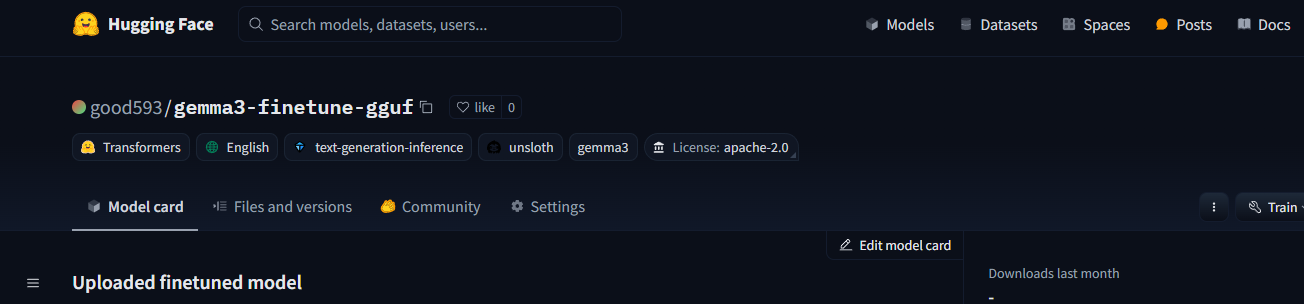